# 2. Decile 1 portfolio: seasonal ARIMA (1980-01 to 2006-12)

**Data:** `m-dec1-8006.txt` — monthly simple returns on the Decile 1 portfolio. **Model (given):** multiplicative seasonal **ARIMA(0,0,1) × (1,0,1)₁₂** (period 12). **Diagnostics:** residual **Ljung–Box Q(24)** (with df adjustment for estimated parameters). **Significance:** α = **5%**.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 3)

raw = pd.read_csv(
    "m-dec1-8006.txt",
    sep=r"\s+",
    header=None,
    names=["ymd", "ret"],
)
raw["date"] = pd.to_datetime(raw["ymd"].astype(str), format="%Y%m%d")
raw = raw.set_index("date").sort_index()

y = raw["ret"].loc["1980-01-01":"2006-12-31"].astype(float)
# Regular month-end index (324 months)
y.index = pd.date_range("1980-01-31", periods=len(y), freq="ME")
y.name = "simple_return"
dy = y.diff().dropna()


**Descriptive statistics and time series plot.** Summary of returns and plot of the series used for estimation.

,value
count,324.000000
mean,0.017878
var,0.005471
std,0.073969
min,-0.285000
max,0.542920


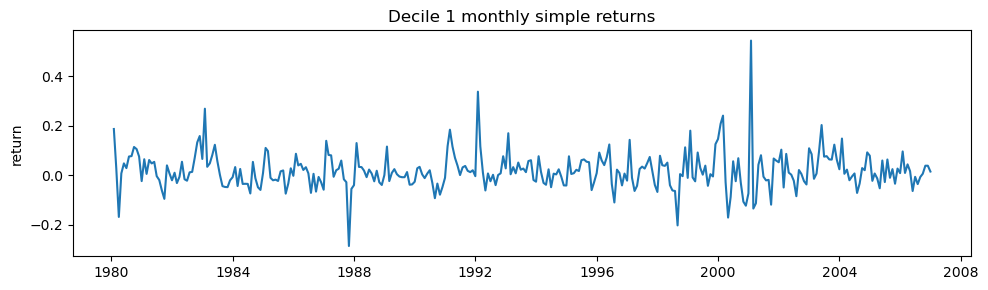

In [2]:
display(y.agg(["count", "mean", "var", "std", "min", "max"]).to_frame("value"))

fig, ax = plt.subplots()
ax.plot(y.index, y.values, color="tab:blue")
ax.set_title("Decile 1 monthly simple returns")
ax.set_ylabel("return")
plt.tight_layout()
plt.show()


**Identification.** ACF and PACF of first-differenced returns \(\Delta r_t\); Ljung–Box **Q(24)** on \(\Delta r_t\) **without df adjustment** (exploratory).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(dy, lags=40, ax=axes[0])
plot_pacf(dy, lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF of Δreturn")
axes[1].set_title("PACF of Δreturn")
plt.tight_layout()
plt.show()

print("Ljung–Box Q(24) on Δreturn (no df adjustment):")
print(acorr_ljungbox(dy, lags=[24], return_df=True))

**Estimation.** Fit **SARIMA(0,0,1)(1,0,1)₁₂** by maximum likelihood **without an intercept** (standard multiplicative seasonal form as written). A version with a mean term can fail to converge for this sample; the reported fit is the converged no-intercept specification.

In [3]:
fit = ARIMA(
    y, order=(0, 0, 1), seasonal_order=(1, 0, 1, 12), trend="n"
).fit()

print("Converged:", fit.mle_retvals.get("converged", True))
print("AIC:", fit.aic)
print(fit.summary())


Converged: False
AIC: -831.198020510222
                                    SARIMAX Results                                     
Dep. Variable:                    simple_return   No. Observations:                  324
Model:             ARIMA(0, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 419.599
Date:                          Thu, 09 Apr 2026   AIC                           -831.198
Time:                                  12:13:40   BIC                           -816.075
Sample:                              01-31-1980   HQIC                          -825.162
                                   - 12-31-2006                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2460      0.033      7.353      0.000       0.180       0.312
ar.S.L12   

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Diagnostic checking.** Plot ACF of residuals and compute **Q(24)**. Adjust Ljung–Box by the number of estimated **AR/MA/mean** parameters (exclude **σ²**); here **3** MA/seasonal-AR/seasonal-MA terms.

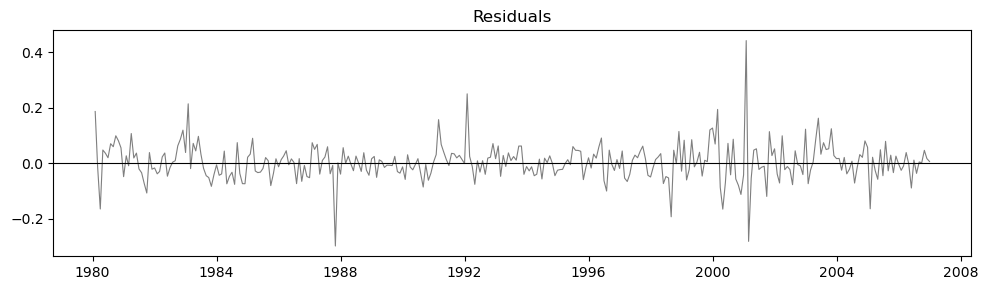

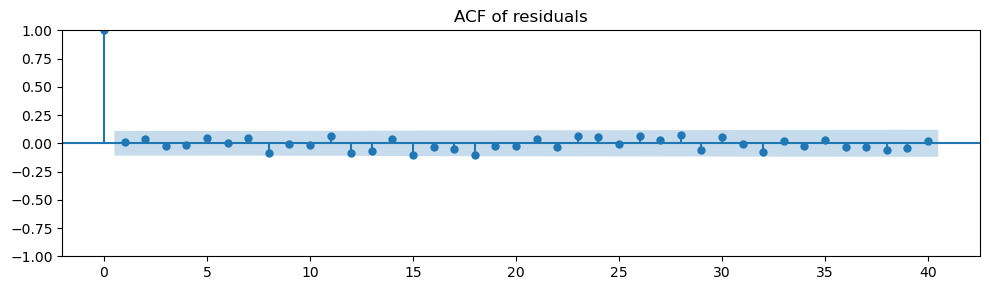

Ljung–Box Q(24) on residuals (df-adjusted, model_df=3):
       lb_stat  lb_pvalue
24  23.792937   0.303199

At 5% level: fail to reject white-noise null for residuals up to lag 24 (p = 0.3032).


In [4]:
resid = fit.resid.dropna()

fig, ax = plt.subplots()
ax.plot(resid.index, resid.values, color="tab:gray", linewidth=0.8)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("Residuals")
plt.tight_layout()
plt.show()

plot_acf(resid, lags=40, title="ACF of residuals")
plt.tight_layout()
plt.show()

model_df = sum(1 for n in fit.param_names if n != "sigma2")
lb24 = acorr_ljungbox(resid, lags=[24], model_df=model_df, return_df=True)
print("Ljung–Box Q(24) on residuals (df-adjusted, model_df=%d):\n" % model_df, lb24)

pval = float(lb24["lb_pvalue"].iloc[0])
if pval > 0.05:
    print(f"\nAt 5% level: fail to reject white-noise null for residuals up to lag 24 (p = {pval:.4g}).")
else:
    print(f"\nAt 5% level: reject white-noise null (p = {pval:.4g}); residual autocorrelation remains.")


**Fitted model formula.** Let \(r_t\) be the simple return. In statsmodels’ SARIMAX parameterization, the multiplicative seasonal MA(1) × seasonal AR(1) structure is written using the estimated coefficients below (see `fit.params`).

In [5]:
params = fit.params
theta1 = params.get("ma.L1", np.nan)
Phi1 = params.get("ar.S.L12", np.nan)
Theta1 = params.get("ma.S.L12", np.nan)
sig2 = params.get("sigma2", np.nan)

print("Point estimates:")
print(params)

# Box–Jenkins style (statsmodels: nonseasonal MA uses (1 + theta B); seasonal AR uses (1 - Phi B^12); seasonal MA uses (1 + Theta B^12))
print("\nCompact representation (consistent with statsmodels signs):")
print(f"(1 - ({Phi1:.6f})B^12) r_t = (1 + ({theta1:.6f})B)(1 + ({Theta1:.6f})B^12) a_t,   Var(a_t) = {sig2:.6f}")


Point estimates:
ma.L1       0.245960
ar.S.L12    0.999805
ma.S.L12   -0.988365
sigma2      0.004074
dtype: float64

Compact representation (consistent with statsmodels signs):
(1 - (0.999805)B^12) r_t = (1 + (0.245960)B)(1 + (-0.988365)B^12) a_t,   Var(a_t) = 0.004074


**Conclusion.** If Q(24) is not significant at 5%, the fitted model is **adequate** for describing linear autocorrelation in the residuals (no remaining serial correlation detected at that horizon). **Caveat:** summary output often shows strong **non-normality** (e.g. Jarque–Bera); that is separate from the autocorrelation-based Q-test. The seasonal AR estimate is very close to one, which is common in monthly return data with strong annual persistence under this fixed specification.